In [1]:
import os
import glob
import zipfile
import warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print("All libraries imported successfully")

All libraries imported successfully


In [3]:
import os

desktop = "/Users/olaoluwaadekanye/Desktop/nasa-battery-rul"

for root, dirs, files in os.walk(desktop):
    for file in files:
        print(os.path.join(root, file))

/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/.DS_Store
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/data:/5.+Battery+Data+Set.zip


In [7]:
import os

desktop = "/Users/olaoluwaadekanye/Desktop"

for root, dirs, files in os.walk(desktop):
    for f in files:
        print(os.path.join(root, f))

/Users/olaoluwaadekanye/Desktop/.DS_Store
/Users/olaoluwaadekanye/Desktop/.localized
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/.DS_Store
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/data:/battery.zip


In [9]:
import os

desktop = "/Users/olaoluwaadekanye/Desktop"

for root, dirs, files in os.walk(desktop):
    for f in files:
        print(os.path.join(root, f))

/Users/olaoluwaadekanye/Desktop/.DS_Store
/Users/olaoluwaadekanye/Desktop/.localized
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/.DS_Store
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/data/.DS_Store
/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/data/battery.zip


In [10]:
import zipfile
import os
import glob

main_zip_path = "/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/data/battery.zip"
extract_root  = "/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/battery_raw"

os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(main_zip_path, 'r') as z:
    z.extractall(extract_root)
    print("Outer zip extracted")

inner_zips = glob.glob(os.path.join(extract_root, '**', '*.zip'), recursive=True)
print(f"Found {len(inner_zips)} inner zip files")

for inner in inner_zips:
    folder_name = os.path.splitext(os.path.basename(inner))[0]
    out_path    = os.path.join(extract_root, folder_name)
    os.makedirs(out_path, exist_ok=True)
    with zipfile.ZipFile(inner, 'r') as z:
        z.extractall(out_path)
    print(f"  Extracted: {os.path.basename(inner)}")

mat_files = glob.glob(os.path.join(extract_root, '**', '*.mat'), recursive=True)
print(f"\nTotal .mat files found: {len(mat_files)}")

Outer zip extracted
Found 6 inner zip files
  Extracted: 2. BatteryAgingARC_25_26_27_28_P1.zip
  Extracted: 1. BatteryAgingARC-FY08Q4.zip
  Extracted: 5. BatteryAgingARC_49_50_51_52.zip
  Extracted: 6. BatteryAgingARC_53_54_55_56.zip
  Extracted: 4. BatteryAgingARC_45_46_47_48.zip
  Extracted: 3. BatteryAgingARC_25-44.zip

Total .mat files found: 38


In [11]:
import scipy.io as sio

# load one file just to inspect
sample_file = mat_files[0]
mat = sio.loadmat(sample_file, simplify_cells=True)

# the battery key is the filename without extension
battery_id = [k for k in mat.keys() if not k.startswith('_')][0]
cycles     = mat[battery_id]['cycle']

print(f"Battery ID     : {battery_id}")
print(f"Total cycles   : {len(cycles)}")
print(f"Cycle fields   : {list(cycles[0].keys())}")
print(f"Cycle types    : {set(c['type'] for c in cycles)}")

# peek at one discharge cycle
for c in cycles:
    if c['type'].strip() == 'discharge':
        print(f"\nDischarge data fields : {list(c['data'].keys())}")
        print(f"Capacity (Ahr)        : {c['data']['Capacity']:.4f}")
        break

Battery ID     : B0052
Total cycles   : 62
Cycle fields   : ['type', 'ambient_temperature', 'time', 'data']
Cycle types    : {'impedance', 'charge', 'discharge'}

Discharge data fields : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity']
Capacity (Ahr)        : 0.8607


In [13]:
def flatten_mat_file(mat_path):
    mat        = sio.loadmat(mat_path, simplify_cells=True)
    battery_id = [k for k in mat.keys() if not k.startswith('_')][0]
    cycles     = mat[battery_id]['cycle']

    ts_rows      = []
    summary_rows = []
    discharge_num = 0

    for cycle_idx, c in enumerate(cycles):
        ctype    = c['type'].strip()
        temp_amb = c.get('ambient_temperature', np.nan)
        data     = c['data']

        if ctype == 'discharge':
            discharge_num += 1

            # handle Capacity being either a scalar or an array
            raw_cap  = data.get('Capacity', np.nan)
            capacity = float(np.array(raw_cap).flatten()[0]) if np.array(raw_cap).size > 0 else np.nan

            v  = np.array(data['Voltage_measured']).flatten()
            i  = np.array(data['Current_measured']).flatten()
            t  = np.array(data['Temperature_measured']).flatten()
            tm = np.array(data['Time']).flatten()

            for j in range(len(tm)):
                ts_rows.append({
                    'battery_id':      battery_id,
                    'discharge_cycle': discharge_num,
                    'cycle_index':     cycle_idx,
                    'ambient_temp_C':  temp_amb,
                    'time_s':          tm[j],
                    'voltage_V':       v[j],
                    'current_A':       i[j],
                    'temperature_C':   t[j],
                    'capacity_Ahr':    capacity,
                })

            summary_rows.append({
                'battery_id':       battery_id,
                'discharge_cycle':  discharge_num,
                'cycle_index':      cycle_idx,
                'ambient_temp_C':   temp_amb,
                'capacity_Ahr':     capacity,
                'avg_voltage_V':    np.mean(v),
                'min_voltage_V':    np.min(v),
                'max_voltage_V':    np.max(v),
                'avg_temp_C':       np.mean(t),
                'max_temp_C':       np.max(t),
                'cycle_duration_s': tm[-1] - tm[0] if len(tm) > 1 else np.nan,
            })

    return pd.DataFrame(ts_rows), pd.DataFrame(summary_rows)


# test it on one file first
test_ts, test_summary = flatten_mat_file(mat_files[0])
print("Time-series shape :", test_ts.shape)
print("Summary shape     :", test_summary.shape)
print("\nTime-series preview:")
display(test_ts.head())
print("\nSummary preview:")
display(test_summary.head())

Time-series shape : (5934, 9)
Summary shape     : (25, 11)

Time-series preview:


,battery_id,discharge_cycle,cycle_index,ambient_temp_C,time_s,voltage_V,current_A,temperature_C,capacity_Ahr
0,B0052,1,0,4,0.000,3.839569,0.003881,9.127700,0.860659
1,B0052,1,0,4,9.313,3.839317,0.000240,9.109016,0.860659
2,B0052,1,0,4,19.406,3.467054,-1.992228,9.069624,0.860659
3,B0052,1,0,4,28.797,3.441731,-1.994519,9.091822,0.860659
4,B0052,1,0,4,38.141,3.420127,-1.993204,9.126609,0.860659



Summary preview:


,battery_id,discharge_cycle,cycle_index,ambient_temp_C,capacity_Ahr,avg_voltage_V,min_voltage_V,max_voltage_V,avg_temp_C,max_temp_C,cycle_duration_s
0,B0052,1,0,4,0.860659,3.134534,2.691234,3.839569,13.147685,16.429875,1713.235
1,B0052,2,4,4,1.418310,3.354329,2.694830,4.150554,11.746282,16.315701,3170.984
2,B0052,3,6,4,1.370712,3.395819,2.696958,4.176525,11.375627,15.689006,3135.344
3,B0052,4,8,4,1.351565,3.398418,2.697283,4.178983,11.242586,14.971276,3049.781
4,B0052,5,10,4,NaN,0.236898,0.226825,0.240971,5.559116,6.581808,4565.859


In [14]:
all_ts      = []
all_summary = []

for path in sorted(mat_files):
    print(f"Processing {os.path.basename(path)} ...", end=' ')
    try:
        ts, sm = flatten_mat_file(path)
        all_ts.append(ts)
        all_summary.append(sm)
        print(f"{len(ts):,} time-steps | {len(sm)} discharge cycles")
    except Exception as e:
        print(f"SKIPPED — {e}")

# combine into one big table each
timeseries_df = pd.concat(all_ts,      ignore_index=True)
summary_df    = pd.concat(all_summary, ignore_index=True)

print(f"\nTotal time-series rows : {len(timeseries_df):,}")
print(f"Total discharge cycles : {len(summary_df):,}")
print(f"Unique batteries       : {summary_df['battery_id'].nunique()}")

Processing B0005.mat ... 50,285 time-steps | 168 discharge cycles
Processing B0006.mat ... 50,285 time-steps | 168 discharge cycles
Processing B0007.mat ... 50,285 time-steps | 168 discharge cycles
Processing B0018.mat ... 34,866 time-steps | 132 discharge cycles
Processing B0025.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0026.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0027.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0028.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0025.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0026.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0027.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0028.mat ... 16,338 time-steps | 28 discharge cycles
Processing B0029.mat ... 6,351 time-steps | 40 discharge cycles
Processing B0030.mat ... 6,351 time-steps | 40 discharge cycles
Processing B0031.mat ... 6,351 time-steps | 40 discharge cycles
Processing B0032.mat ...

In [15]:
os.makedirs('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs', exist_ok=True)

timeseries_df.to_csv('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/battery_timeseries.csv', index=False)
summary_df.to_csv('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/battery_cycle_summary.csv', index=False)

print("Saved:")
print("  outputs/battery_timeseries.csv")
print("  outputs/battery_cycle_summary.csv")

Saved:
  outputs/battery_timeseries.csv
  outputs/battery_cycle_summary.csv


In [16]:
EOL_CAPACITY = 1.4  # end-of-life threshold (30% fade from 2 Ahr)

def add_rul(df):
    rows = []
    for battery_id, grp in df.groupby('battery_id'):
        grp  = grp.sort_values('discharge_cycle').copy()

        # find the first cycle where capacity hits end-of-life
        eol_mask = grp['capacity_Ahr'] <= EOL_CAPACITY
        if eol_mask.any():
            eol_cycle = grp.loc[eol_mask, 'discharge_cycle'].iloc[0]
        else:
            eol_cycle = grp['discharge_cycle'].max()

        grp['eol_cycle'] = eol_cycle
        grp['rul']       = (eol_cycle - grp['discharge_cycle']).clip(lower=0)
        rows.append(grp)

    return pd.concat(rows, ignore_index=True)

summary_df = add_rul(summary_df)

print(f"RUL range: {int(summary_df['rul'].min())} – {int(summary_df['rul'].max())} cycles")
display(summary_df[['battery_id', 'discharge_cycle', 'capacity_Ahr', 'eol_cycle', 'rul']].head(10))

RUL range: 0 – 167 cycles


,battery_id,discharge_cycle,capacity_Ahr,eol_cycle,rul
0,B0005,1,1.856487,125,124
1,B0005,2,1.846327,125,123
2,B0005,3,1.835349,125,122
3,B0005,4,1.835263,125,121
4,B0005,5,1.834646,125,120
5,B0005,6,1.835662,125,119
6,B0005,7,1.835146,125,118
7,B0005,8,1.825757,125,117
8,B0005,9,1.824774,125,116
9,B0005,10,1.824613,125,115


In [17]:
def engineer_features(df):
    rows = []
    for battery_id, grp in df.groupby('battery_id'):
        grp = grp.sort_values('discharge_cycle').copy()
        initial_cap             = grp['capacity_Ahr'].iloc[0]
        grp['capacity_fade']    = initial_cap - grp['capacity_Ahr']
        grp['rolling_cap_mean'] = grp['capacity_Ahr'].rolling(5, min_periods=1).mean()
        rows.append(grp)
    return pd.concat(rows, ignore_index=True)

summary_df = engineer_features(summary_df)
summary_df.to_csv('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/battery_cycle_summary_with_rul.csv', index=False)

print("Saved: outputs/battery_cycle_summary_with_rul.csv")
display(summary_df.head())

Saved: outputs/battery_cycle_summary_with_rul.csv


,battery_id,discharge_cycle,cycle_index,ambient_temp_C,capacity_Ahr,avg_voltage_V,min_voltage_V,max_voltage_V,avg_temp_C,max_temp_C,cycle_duration_s,eol_cycle,rul,capacity_fade,rolling_cap_mean
0,B0005,1,1,24,1.856487,3.529829,2.612467,4.191492,32.572328,38.982181,3690.234,125,124,0.000000,1.856487
1,B0005,2,3,24,1.846327,3.537320,2.587209,4.189773,32.725235,39.033398,3672.344,125,123,0.010160,1.851407
2,B0005,3,5,24,1.835349,3.543737,2.651917,4.188187,32.642862,38.818797,3651.641,125,122,0.021138,1.846055
3,B0005,4,7,24,1.835263,3.543666,2.592948,4.188461,32.514876,38.762305,3631.563,125,121,0.021225,1.843357
4,B0005,5,9,24,1.834646,3.542343,2.547420,4.188299,32.382349,38.665393,3629.172,125,120,0.021842,1.841614


In [18]:
FEATURE_COLS = [
    'discharge_cycle',
    'capacity_Ahr',
    'avg_voltage_V',
    'min_voltage_V',
    'max_voltage_V',
    'avg_temp_C',
    'max_temp_C',
    'cycle_duration_s',
    'ambient_temp_C',
    'capacity_fade',
    'rolling_cap_mean',
]

df_model = summary_df.dropna(subset=FEATURE_COLS + ['rul'])
X = df_model[FEATURE_COLS]
y = df_model['rul']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale for linear regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    results[name] = {
        'model': model,
        'preds': preds,
        'MAE':   round(mean_absolute_error(y_test, preds), 2),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R2':    round(r2_score(y_test, preds), 4),
    }
    print(f"{name:25s} | MAE={results[name]['MAE']:6.2f} | RMSE={results[name]['RMSE']:6.2f} | R²={results[name]['R2']:.4f}")

Linear Regression         | MAE= 14.79 | RMSE= 20.21 | R²=0.4897
Random Forest             | MAE=  0.68 | RMSE=  1.66 | R²=0.9966
Gradient Boosting         | MAE=  2.54 | RMSE=  4.17 | R²=0.9783


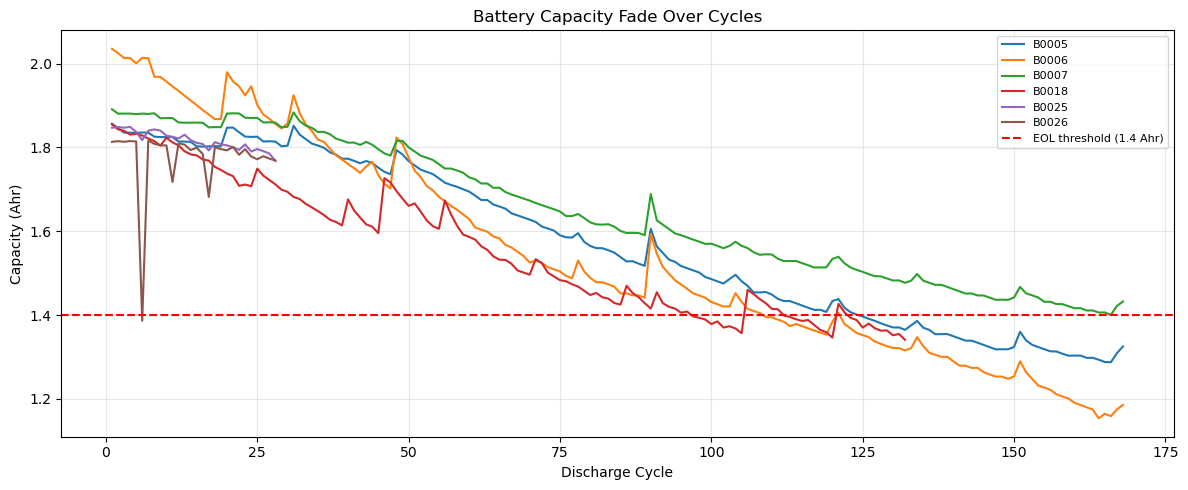

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

sample_ids = summary_df['battery_id'].unique()[:6]
for bid in sample_ids:
    grp = summary_df[summary_df['battery_id'] == bid].sort_values('discharge_cycle')
    ax.plot(grp['discharge_cycle'], grp['capacity_Ahr'], label=bid, linewidth=1.5)

ax.axhline(1.4, color='red', linestyle='--', label='EOL threshold (1.4 Ahr)')
ax.set_xlabel('Discharge Cycle')
ax.set_ylabel('Capacity (Ahr)')
ax.set_title('Battery Capacity Fade Over Cycles')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/1_capacity_fade.png', dpi=150)
plt.show()

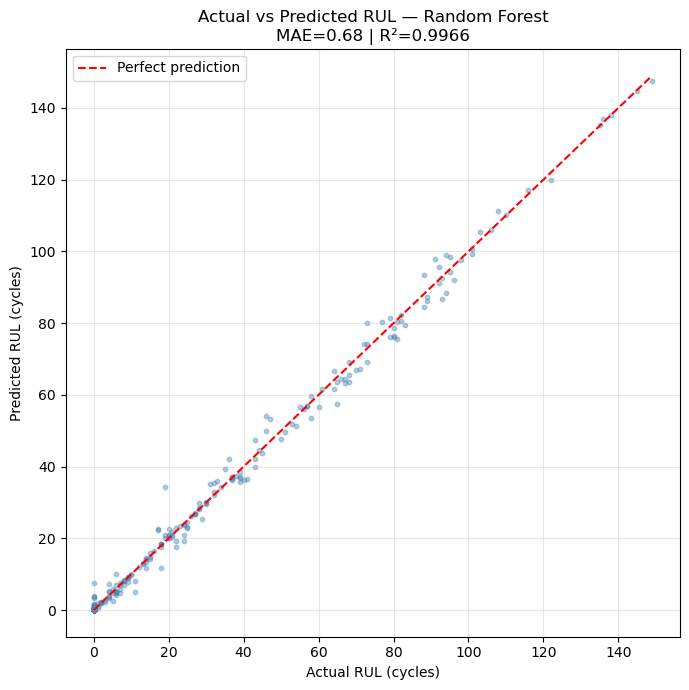

In [20]:
best_name = max(results, key=lambda k: results[k]['R2'])
preds     = results[best_name]['preds']

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds, alpha=0.4, s=10, color='steelblue')
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title(f'Actual vs Predicted RUL — {best_name}\nMAE={results[best_name]["MAE"]} | R²={results[best_name]["R2"]}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/2_actual_vs_predicted_rul.png', dpi=150)
plt.show()

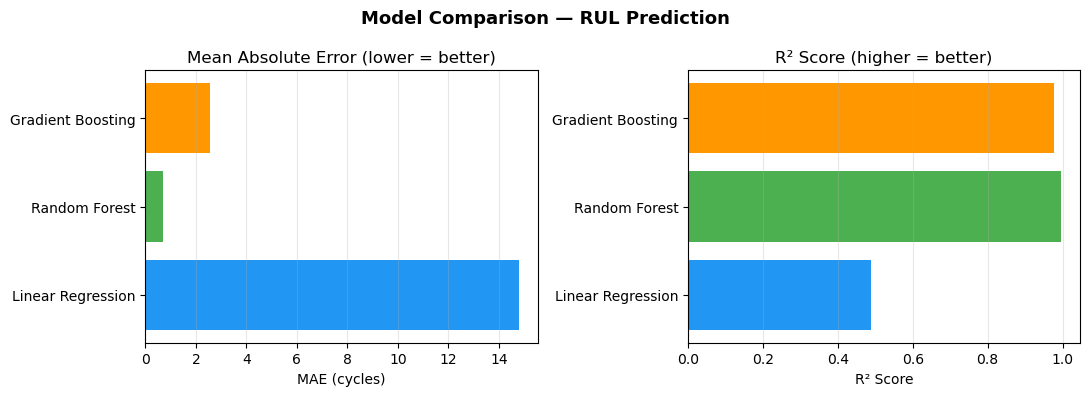

In [21]:
names = list(results.keys())
maes  = [results[k]['MAE'] for k in names]
r2s   = [results[k]['R2']  for k in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(names, maes, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0].set_xlabel('MAE (cycles)')
axes[0].set_title('Mean Absolute Error (lower = better)')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(names, r2s, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² Score (higher = better)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Model Comparison — RUL Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/3_model_comparison.png', dpi=150)
plt.show()

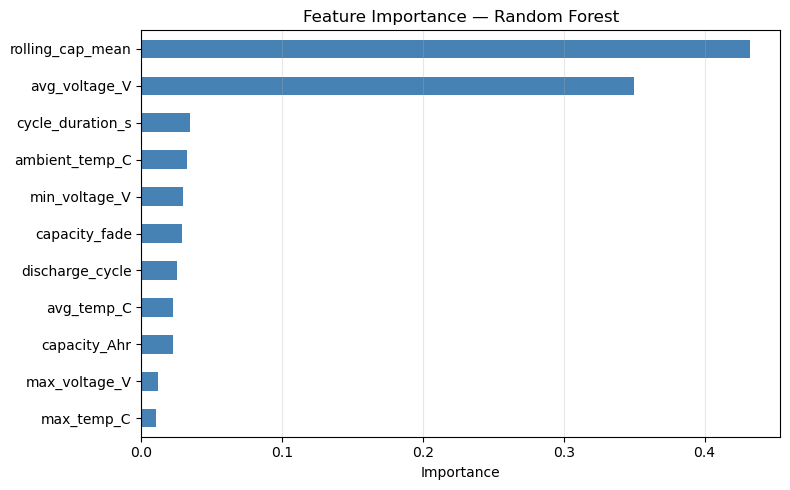

In [22]:
rf       = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/Users/olaoluwaadekanye/Desktop/nasa-battery-rul/outputs/4_feature_importance.png', dpi=150)
plt.show()